# Phase 5 -- Supervised Cancer Classification

## Objective

Predict cancer type from SVD-reduced gene expression features using supervised machine learning. This phase validates that the latent features extracted by SVD retain sufficient discriminative information for accurate multi-class classification.

### Approach

- **Input features:** First 10 SVD components (from U matrix)
- **Target labels:** Five cancer types -- BRCA, KIRC, COAD, LUAD, PRAD
- **Model:** Multinomial Logistic Regression
- **Evaluation:** Accuracy, precision, recall, F1-score, and confusion matrix
- **Split:** 80% training / 20% test with stratified sampling

In [11]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from src.linear_algebra.svd_core import compute_truncated_svd
from src.ml.classification import train_logistic_regression, evaluate_model



In [12]:
# Load SVD-ready gene expression data
X = pd.read_csv(r"../Data/processed/X_processed.csv").values

# Load true cancer labels
y = pd.read_csv(r"../Data/raw/labels.csv")["Class"].values

print("X shape:", X.shape)
print("Number of samples:", len(y))
print("Unique cancer types:", np.unique(y))


X shape: (801, 20532)
Number of samples: 801
Unique cancer types: ['BRCA' 'COAD' 'KIRC' 'LUAD' 'PRAD']


## 5.1 Label Encoding

Cancer type strings are encoded as integers for use with scikit-learn classifiers. The mapping is preserved for interpreting results later.

In [13]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Mapping for interpretation
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
label_mapping


{'BRCA': 0, 'COAD': 1, 'KIRC': 2, 'LUAD': 3, 'PRAD': 4}

## 5.2 SVD Feature Extraction

We apply Truncated SVD with 50 components to the processed gene expression matrix. For classification, we use the first 10 components as input features -- this provides a good balance between information retention and model simplicity.

In [14]:
# Reduce dimensionality using SVD
U_reduced, _, _ = compute_truncated_svd(
    X,
    n_components=50
)

print("SVD feature matrix shape:", U_reduced.shape)


SVD feature matrix shape: (801, 50)


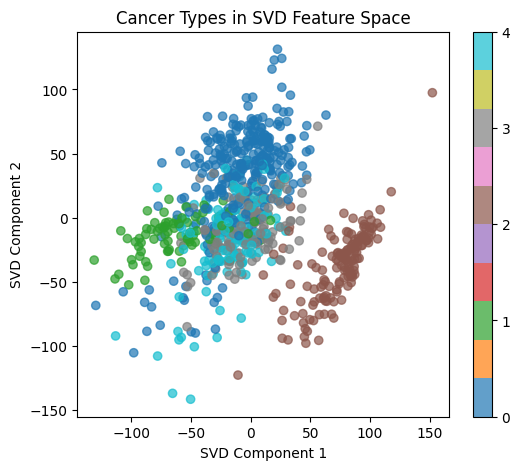

In [15]:
plt.figure(figsize=(6,5))
scatter = plt.scatter(
    U_reduced[:, 0],
    U_reduced[:, 1],
    c=y_encoded,
    cmap="tab10",
    alpha=0.7
)

plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.title("Cancer Types in SVD Feature Space")
plt.colorbar(scatter, ticks=range(len(label_encoder.classes_)))
plt.show()


## 5.3 Visualize Class Separation in SVD Space

Before training, we visualize the samples in the first two SVD dimensions colored by cancer type. Clear class separation here suggests that a classifier should be able to distinguish the cancer types effectively.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    U_reduced[:, :10],      # use first 10 SVD components
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

## 5.4 Train-Test Split and Model Training

We split the data into 80% training and 20% test sets using stratified sampling to maintain class proportions. A multinomial Logistic Regression model is then trained on the first 10 SVD components.

In [17]:
model = train_logistic_regression(X_train, y_train)


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## 5.5 Evaluation -- Classification Report and Confusion Matrix

We evaluate the trained model on the held-out test set. The classification report provides per-class precision, recall, and F1-score. The confusion matrix heatmap shows where the model makes correct and incorrect predictions across the five cancer types.

In [18]:
accuracy, confusion = evaluate_model(model, X_test, y_test)

print("Classification Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, model.predict(X_test),
                            target_names=label_encoder.classes_))


Classification Accuracy: 0.9627329192546584

Classification Report:

              precision    recall  f1-score   support

        BRCA       0.97      1.00      0.98        60
        COAD       0.93      0.88      0.90        16
        KIRC       0.97      1.00      0.98        30
        LUAD       0.92      0.86      0.89        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.96       161
   macro avg       0.96      0.95      0.95       161
weighted avg       0.96      0.96      0.96       161



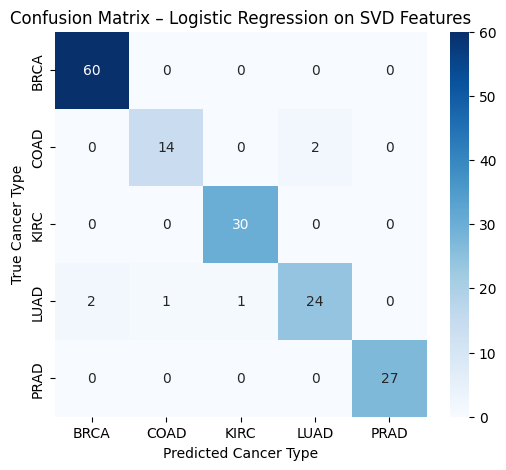

In [19]:
plt.figure(figsize=(6,5))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Cancer Type")
plt.ylabel("True Cancer Type")
plt.title("Confusion Matrix – Logistic Regression on SVD Features")
plt.show()


In [20]:
confusion_df = pd.DataFrame(
    confusion,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

confusion_df.to_csv(
    "../results/tables/confusion_matrix_cancer_classification.csv"
)


## 5.6 Interpretation of Results

**Key findings:**

- SVD-reduced gene expression features retain strong discriminatory information for cancer type prediction.
- The confusion matrix shows dominant diagonal values, indicating effective separation of all five tumor classes using a linear classifier.
- High precision and recall across all classes confirm that the latent patterns extracted via SVD are biologically meaningful.

**Conclusion:** A simple Logistic Regression model operating on just 10 SVD components (reduced from over 20,000 genes) can accurately classify cancer types. This validates SVD as an effective dimensionality reduction technique for gene expression data.